# EDA (exploratory data analisis) de ventas de retail

Descripcion de las columnas:
- **Transaction ID:** Identificador unico para cada transaccion, permitiendo el seguimiento y la referencia.
- **Date:** La fecha cuando la transaccion se efectuo, proporciona informacion sobre las tendencias de venta a lo largo del tiempo.
- **Customer ID:** Identificador unico para cada cliente, permitiendo un analisis centrado en el cliente.
- **Gender:** Genero del cliente (Male/Female), ofreciendo informacion sobre los patrones de compra segun el genero.
- **Age:** Años deñ cliente, facilitando segmentacion y exploracion en las influencias relacionadas con la edad.
- **Product Category:** Categoria del producto comprado (Electronics, Clothings, Beauty), ayudando a entender la preferencia de productos.
- **Quantity:** Numero de unidades de un producto comprado, contribuyendo a la informacion sobre los columenes de compra.
- **Price per Unit:** Precio de una unidad de producto, ayudando en los calculos relacionados con el gasto total.
- **Total Amount:** Total monetario de la transaccion, mostrando el impacto financiero de cada compra.


Importacion de librerias

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Carga y visualizacion de los datos

In [2]:
df = pd.read_csv('data/data_eda/retail_sales_dataset.csv')
df.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


Se aprecia que no hay datos nulos a simple vista.

In [4]:
df.shape

(1000, 9)

Se observa que el dataset tiene 1000 filas con 9 columnas antes mencionadas.

## Preguntas a trabajar en el dataset

1. ¿Existen patrones identificables en las ventas a lo largo de distintos períodos de tiempo?
2. ¿Qué categorías de producto tienen mayor atractivo entre los clientes?
3. ¿Cuáles son las relaciones entre edad, gasto y preferencias de producto?
4. ¿Cómo adaptan los clientes sus hábitos de compra durante las tendencias estacionales?
5. ¿Existen comportamientos de compra distintos según la cantidad de artículos comprados por transacción?
6. ¿Qué información se puede obtener a partir de la distribución de precios de productos dentro de cada categoría?

## Limpieza y transformacion de datos

### Busqueda de nulos

Primero realizamos una busqueda de nulos en las columnas

In [5]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Se aprecia que no existen datos nulos o faltantes.

### Transformacion de datos

Revisaremos columnas categoricas como "Product Category" o "Gender", y asegurarnos que todos los datos estan iguales.

In [6]:
df['Product Category'].unique()

<StringArray>
['Beauty', 'Clothing', 'Electronics']
Length: 3, dtype: str

In [7]:
df['Gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

Ya que la fecha es algo importante y anteriormente aparece como "STR", transformaremos el tipo de datos a datetime para poder utilizarlo de manera mas facil.

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df.head(3)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30


## Analisis y respuesta de preguntas

1. ¿Existen patrones identificables en las ventas a lo largo de distintos períodos de tiempo?
2. ¿Qué categorías de producto tienen mayor atractivo entre los clientes?
3. ¿Cuáles son las relaciones entre edad, gasto y preferencias de producto?
4. ¿Cómo adaptan los clientes sus hábitos de compra durante las tendencias estacionales?
5. ¿Existen comportamientos de compra distintos según la cantidad de artículos comprados por transacción?
6. ¿Qué información se puede obtener a partir de la distribución de precios de productos dentro de cada categoría?

### 1. ¿Existen patrones identificables en las ventas a lo largo de distintos períodos de tiempo?

Para entender mejor el periodo de tiempo veremos cuanto tiempo de datos tenemos.

In [10]:
min = df['Date'].min()
max = df['Date'].max()

print(min)
print(max)

2023-01-01 00:00:00
2024-01-01 00:00:00


Se aprecia que tenemos 1 año de datos por lo que el periodo de tiempo sera por estacion del año y ya que el dataset esta en ingles utilizaremos los meses de estaciones de Estados Unidos.

In [11]:
def obtener_estacion(mes):
    if mes in [12,1,2]:
        return 'Invierno'
    elif mes in [3,4,5]:
        return 'Primavera'
    elif mes in[6,7,8]:
        return 'Verano'
    else:
        return 'Otoño'
    
df['Season'] = df['Date'].dt.month.apply(obtener_estacion)
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Season
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,Otoño
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,Invierno
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,Invierno
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,Primavera
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,Primavera


In [12]:
df.groupby(['Season'])['Total Amount'].agg(['mean', 'median']).round(2)


,mean,median
Season,,
Invierno,495.00,150.0
Otoño,439.83,120.0
Primavera,439.43,120.0
Verano,449.14,120.0


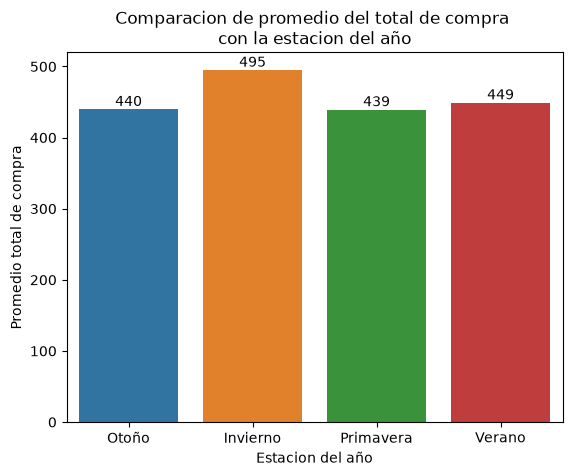

In [13]:
ax = sns.barplot(x='Season', y='Total Amount', data=df, estimator='mean', errorbar=None, hue="Season",)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')
plt.xlabel('Estacion del año')
plt.ylabel('Promedio total de compra')
plt.title('Comparacion de promedio del total de compra \ncon la estacion del año')
plt.show()

Se aprecia que en invierno hay un mayor promedio en el total de compra en comparacion con las demas estaciones, por lo que puede significar que en esa temporada ya que hace frio pueden comprar mas ropa para abrigarse del frio.

In [14]:
df.groupby(['Season', 'Product Category'])['Total Amount'].agg(['mean', 'median']).round(2)

mean  median
Season    Product Category                
Invierno  Beauty            524.22   120.0
          Clothing          467.71   150.0
          Electronics       495.76   175.0
Otoño     Beauty            412.83   100.0
          Clothing          506.45   200.0
          Electronics       405.23   100.0
Primavera Beauty            447.44   175.0
          Clothing          418.56   120.0
          Electronics       462.00   150.0
Verano    Beauty            485.20   200.0
          Clothing          390.82   100.0
          Electronics       470.34   150.0

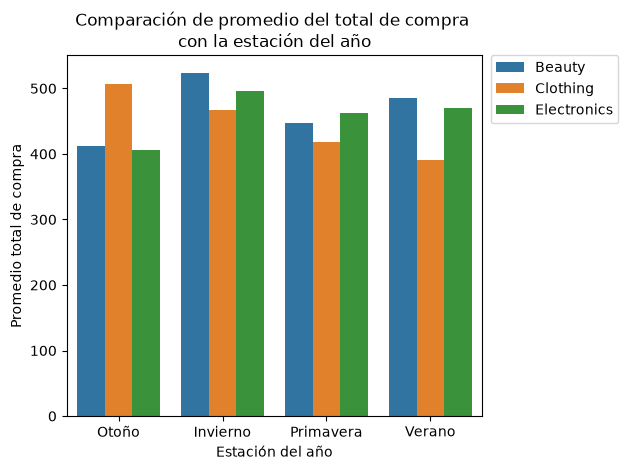

In [15]:
sns.barplot(x='Season', y='Total Amount', data=df, estimator='mean', errorbar=None, hue="Product Category")
plt.xlabel('Estación del año')
plt.ylabel('Promedio total de compra')
plt.title('Comparación de promedio del total de compra \ncon la estación del año')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

Aunque si especificamos mejor el grafico y los datos se aprecia que en agosto hay un mayor promedio de total de compra que tiene que ver con la ropa que debe ser las personas preparandose para invierno y invierno con un gran aumento en productos de belleza para cuidar la piel del frio.

### 2. ¿Qué categorías de producto tienen mayor atractivo entre los clientes?

In [16]:
df['Product Category'].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

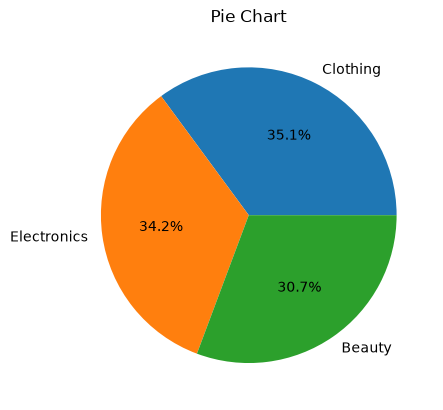

In [17]:
plt.pie(df['Product Category'].value_counts(), labels=['Clothing', 'Electronics', 'Beauty'], autopct= '%1.1f%%')
plt.title('Pie Chart')
plt.show()

La ropa es la categoria mas atractivo por los clientes esto puede estar directamente relacionado con la moda de temporadas o rebajas.

In [18]:
df[['Product Category', 'Gender']].value_counts()

Product Category  Gender
Clothing          Male      177
                  Female    174
Electronics       Male      172
                  Female    170
Beauty            Female    166
                  Male      141
Name: count, dtype: int64

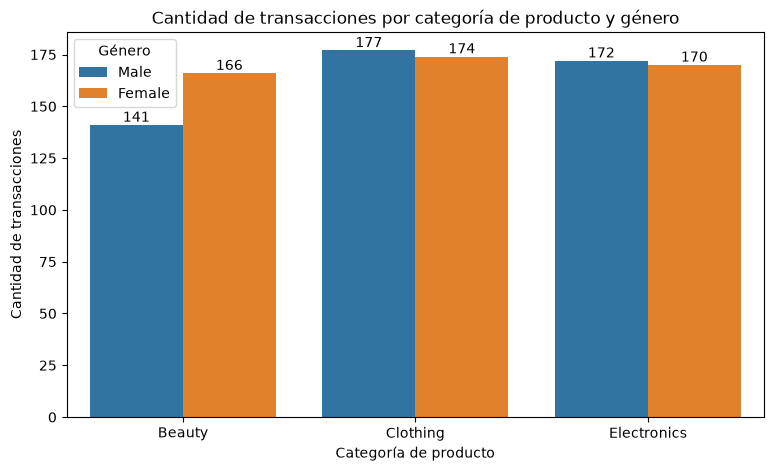

In [19]:
plt.figure(figsize=(9,5))
ax = sns.countplot(data=df, x='Product Category', hue='Gender')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Cantidad de transacciones por categoría de producto y género')
plt.xlabel('Categoría de producto')
plt.ylabel('Cantidad de transacciones')
plt.legend(title='Género')
plt.show()

Comparando los generos y sus preferencias en categorias de compra, se aprecia que en belleza las mujeres tienen una mayor tendencia y en ropa aunque estan muy parecidos se aprecia que el hombre es el que tiene mas preferencia.

### 3. ¿Cuáles son las relaciones entre edad, gasto y preferencias de producto?

In [20]:
bins = [17, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65']

df['Age Range'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

df.groupby('Age Range')['Total Amount'].mean().round(2)

Age Range
18-25    500.30
26-35    480.39
36-45    454.80
46-55    439.69
56-65    412.36
Name: Total Amount, dtype: float64

¿El gasto promedio cambia segun el rango de edad? 

Si, el gasto va en descenso a medida que una persona va envejeciendo el gasto promedio igual va disminuyendo, siendo el mas alto en un rango de edad de entre 18-25 años.

In [21]:
# Categoría más comprada por rango de edad
df.groupby(['Age Range', 'Product Category']).size()

Age Range  Product Category
18-25      Beauty              60
           Clothing            51
           Electronics         58
26-35      Beauty              67
           Clothing            74
           Electronics         64
36-45      Beauty              54
           Clothing            76
           Electronics         72
46-55      Beauty              71
           Clothing            76
           Electronics         82
56-65      Beauty              55
           Clothing            74
           Electronics         66
dtype: int64

¿Qué categoría de producto prefiere cada rango de edad?

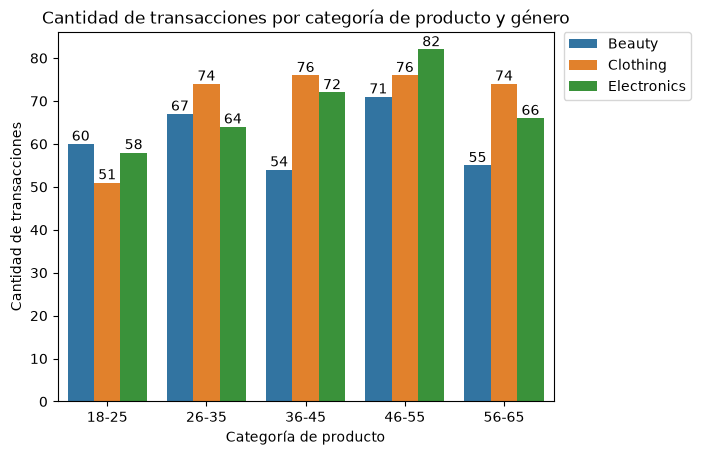

In [22]:
ax = sns.countplot(data=df, x='Age Range', hue='Product Category')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Cantidad de transacciones por categoría de producto y género')
plt.xlabel('Categoría de producto')
plt.ylabel('Cantidad de transacciones')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.show()

In [23]:
pivot = df.pivot_table(
    index='Age Range', 
    columns='Product Category', 
    values='Total Amount', 
    aggfunc='mean', 
    fill_value=0
    )
pivot

Product Category,Beauty,Clothing,Electronics
Age Range,,,
18-25,521.333333,519.803922,461.379310
26-35,466.268657,540.202703,426.015625
36-45,526.018519,388.815789,471.041667
46-55,489.014085,401.118421,432.743902
56-65,324.909091,392.702703,507.272727


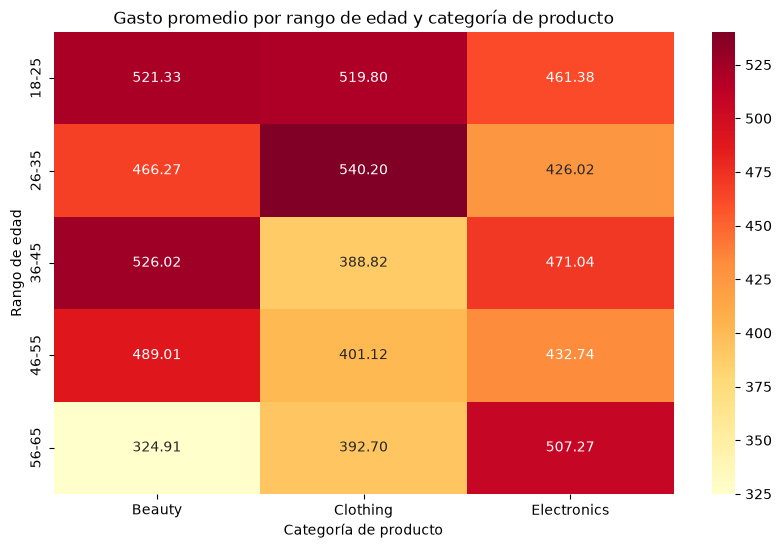

In [24]:
plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Gasto promedio por rango de edad y categoría de producto')
plt.xlabel('Categoría de producto')
plt.ylabel('Rango de edad')
plt.show()

Respondiendo a la pregunta "¿Cuáles son las relaciones entre edad, gasto y preferencias de producto?" 


El análisis cruzado entre edad, categoría de producto y gasto revela que las 
preferencias de compra cambian de forma clara según el rango etario del cliente. 
Los clientes más jóvenes (18-25 y 26-35 años) concentran su gasto principalmente 
en Clothing y Beauty, con montos promedio superiores a $500 en varias combinaciones. 
En contraste, el grupo de mayor edad (56-65 años) invierte notoriamente menos en 
Beauty ($325, el valor más bajo de toda la tabla) y más en Electronics ($507, su 
categoría preferida), un patrón inverso al de los grupos más jóvenes.

Esto sugiere que Beauty tiene mayor atractivo entre clientes jóvenes y de mediana 
edad, mientras que Electronics gana relevancia a medida que aumenta la edad del 
cliente — posiblemente reflejando distintas prioridades de consumo entre 
generaciones. Clothing, por su parte, se mantiene relativamente fuerte en casi 
todos los grupos, siendo la categoría con el gasto promedio más alto en el rango 
26-35 años.

**Recomendación:** campañas de marketing segmentadas por edad podrían ser más 
efectivas que un enfoque genérico — por ejemplo, promociones de Beauty dirigidas 
a clientes bajo 45 años, y de Electronics enfocadas en clientes de 56 años en 
adelante.

### 4. ¿Cómo adaptan los clientes sus hábitos de compra durante las tendencias estacionales?


In [25]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Season,Age Range
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,Otoño,26-35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,Invierno,26-35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,Invierno,46-55
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,Primavera,36-45
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,Primavera,26-35
